# Stochastic Job Shop Simulation: Scheduling Rule Comparison

이 노트북은 Job A, B, C 타입의 여러 job이 M1, M2, M3를 거치는 job shop을 **이산사건 시뮬레이션**으로 모델링하고, scheduling rule 변화에 따른 결과를 비교한다.

핵심 학습 목표는 다음과 같다.

- 확률적 처리시간과 확률적 도착시간을 가진 job shop을 모델링한다.
- A/B/C 타입별 job이 여러 개 생성되는 현실적인 queue 상황을 만든다.
- machine queue에서 어떤 job을 먼저 처리할지 scheduling rule로 결정한다.
- 같은 난수 시나리오를 여러 rule에 적용해 공정하게 비교한다.
- 단일 실행의 event log와 Gantt chart를 확인한다.
- 반복실험 replication을 통해 평균, 변동성, 신뢰구간을 비교한다.


## 1. 라이브러리 준비

이 예제는 `simpy`, `numpy`, `pandas`, `matplotlib`를 사용한다. `seaborn`은 있으면 boxplot을 조금 더 보기 좋게 그리는 데 사용한다.

패키지가 없다면 아래 셀에서 자동 설치를 시도한다.

In [15]:
import importlib.util
import subprocess
import sys

# 노트북 실행에 반드시 필요한 패키지
required_packages = ["simpy", "numpy", "pandas", "matplotlib"]

# 없어도 실행은 가능하지만, 시각화 품질을 높여주는 선택 패키지
optional_packages = ["seaborn"]

# 현재 환경에 설치되지 않은 필수/선택 패키지를 확인
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
missing_optional = [pkg for pkg in optional_packages if importlib.util.find_spec(pkg) is None]

# 필수 패키지가 없으면 자동 설치
if missing:
    print("Installing missing required packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

# 선택 패키지는 없더라도 경고만 출력
if missing_optional:
    print("Optional packages are missing:", missing_optional)
    print("The notebook will still run. Install seaborn if you want styled boxplots.")

In [16]:
from dataclasses import dataclass
from itertools import count
import math

import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# seaborn이 설치되어 있으면 boxplot 시각화에 사용
try:
    import seaborn as sns
    HAS_SEABORN = True
except ModuleNotFoundError:
    HAS_SEABORN = False

# 전체 그래프의 기본 크기와 grid 스타일 설정
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("Ready")

Ready


## 2. 문제 정의

각 job은 A, B, C 중 하나의 타입을 가지며, 타입별로 정해진 routing을 따라 여러 machine을 방문한다. 처리시간은 고정값이 아니라 triangular distribution에서 생성한다.

- `A`: M1 -> M2 -> M3
- `B`: M2 -> M1 -> M3
- `C`: M1 -> M3 -> M2

`JOB_COUNTS`는 한 replication에서 생성할 타입별 job 개수다. 예를 들어 `{"A": 8, "B": 8, "C": 8}`이면 A01~A08, B01~B08, C01~C08 총 24개 job이 생성된다.

Triangular distribution은 `min`, `mode`, `max`를 직접 설명할 수 있어서 교육용 입력모델로 쓰기 좋다.


In [17]:
# 시뮬레이션에 사용되는 기계 목록
MACHINES = ["M1", "M2", "M3"]

# 제품 유형별 작업 경로, 공정시간 분포, 납기 계수 정의
JOB_TEMPLATES = {
    "A": {
        "route": [("M1", (2, 3, 6)), ("M2", (1, 2, 4)), ("M3", (3, 4, 7))],
        "due_factor": 1.7,
    },
    "B": {
        "route": [("M2", (1, 3, 5)), ("M1", (2, 4, 6)), ("M3", (2, 3, 5))],
        "due_factor": 1.6,
    },
    "C": {
        "route": [("M1", (2, 5, 7)), ("M3", (1, 2, 4)), ("M2", (2, 3, 6))],
        "due_factor": 1.8,
    },
}

# 한 번의 replication에서 생성할 제품 유형별 job 수
JOB_COUNTS = {"A": 8, "B": 8, "C": 8}

# 비교할 dispatching rule 목록
RULES = ["FCFS", "SPT", "LPT", "EDD", "RANDOM"]

# 입력 데이터 구조를 표 형태로 확인
pd.DataFrame([
    {
        "job_type": job_type,
        "jobs_per_replication": JOB_COUNTS[job_type],
        "operation": i + 1,
        "machine": machine,
        "processing_time_distribution": f"Triangular{dist}",
    }
    for job_type, spec in JOB_TEMPLATES.items()
    for i, (machine, dist) in enumerate(spec["route"])
])

,job_type,jobs_per_replication,operation,machine,processing_time_distribution
0,A,8,1,M1,"Triangular(2, 3, 6)"
1,A,8,2,M2,"Triangular(1, 2, 4)"
2,A,8,3,M3,"Triangular(3, 4, 7)"
3,B,8,1,M2,"Triangular(1, 3, 5)"
4,B,8,2,M1,"Triangular(2, 4, 6)"
5,B,8,3,M3,"Triangular(2, 3, 5)"
6,C,8,1,M1,"Triangular(2, 5, 7)"
7,C,8,2,M3,"Triangular(1, 2, 4)"
8,C,8,3,M2,"Triangular(2, 3, 6)"


## 3. 확률 시나리오 생성

Scheduling rule을 비교할 때 중요한 점은 같은 replication에서는 모든 rule이 같은 입력 시나리오를 사용해야 한다는 것이다.

아래 함수는 seed 하나로 다음을 미리 생성한다.

- job 인스턴스별 arrival time
- operation별 processing time
- job별 due date

이렇게 생성한 동일한 scenario를 FCFS, SPT, LPT, EDD, RANDOM에 모두 적용한다.

여기서 랜덤성이 없어지는 것은 아니다. Replication마다 다른 seed를 사용하므로 매 replication마다 새로운 도착시간과 처리시간이 만들어진다. 다만 같은 replication 안에서는 rule끼리 같은 입력을 공유한다.


In [18]:
def build_job_plan(job_counts):
    planned_jobs = []
    max_count = max(job_counts.values())

    # A01, B01, C01, A02, B02, C02처럼 job을 균형 있게 생성
    for copy_idx in range(1, max_count + 1):
        for job_type in JOB_TEMPLATES:
            if copy_idx <= job_counts.get(job_type, 0):
                planned_jobs.append((f"{job_type}{copy_idx:02d}", job_type))

    return planned_jobs


def generate_scenario(seed, arrival_mode="stochastic", mean_interarrival=0.8, job_counts=None):
    # seed를 고정해 같은 scenario를 재현 가능하게 만듦
    rng = np.random.default_rng(seed)

    scenario = {}
    current_arrival = 0.0
    job_counts = job_counts or JOB_COUNTS
    planned_jobs = build_job_plan(job_counts)

    for idx, (job_id, job_type) in enumerate(planned_jobs):
        spec = JOB_TEMPLATES[job_type]

        # arrival_mode에 따라 모든 job이 동시에 도착하거나 확률적으로 도착
        if arrival_mode == "all_zero":
            arrival = 0.0
        elif arrival_mode == "stochastic":
            arrival = 0.0 if idx == 0 else current_arrival + rng.exponential(mean_interarrival)
            current_arrival = arrival
        else:
            raise ValueError("arrival_mode must be 'all_zero' or 'stochastic'")

        operations = []
        nominal_total = 0.0

        # 각 operation의 processing time을 triangular distribution에서 샘플링
        for op_id, (machine, dist) in enumerate(spec["route"], start=1):
            low, mode, high = dist
            processing_time = float(rng.triangular(low, mode, high))
            nominal_total += mode

            operations.append({
                "op_id": op_id,
                "machine": machine,
                "processing_time": processing_time,
                "distribution": dist,
            })

        # 납기는 도착시간 + nominal processing time 합계 * due factor
        due_date = arrival + spec["due_factor"] * nominal_total

        scenario[job_id] = {
            "job_type": job_type,
            "arrival": arrival,
            "due_date": due_date,
            "operations": operations,
        }

    return scenario


# 예시 scenario 생성 후 앞부분 확인
sample_scenario = generate_scenario(seed=2026)
sample_df = pd.DataFrame([
    {
        "job": job,
        "job_type": spec["job_type"],
        "arrival": spec["arrival"],
        "due_date": spec["due_date"],
        "route": " -> ".join(op["machine"] for op in spec["operations"]),
        "sampled_processing_times": [round(op["processing_time"], 2) for op in spec["operations"]],
    }
    for job, spec in sample_scenario.items()
])

print(f"Number of jobs in one replication: {len(sample_df)}")
display(sample_df.head(12))

Number of jobs in one replication: 24


,job,job_type,arrival,due_date,route,sampled_processing_times
0,A01,A,0.000000,15.300000,M1 -> M2 -> M3,"[2.85, 2.53, 4.47]"
1,B01,B,0.549062,16.549062,M2 -> M1 -> M3,"[2.69, 4.71, 4.25]"
2,C01,C,0.563937,18.563937,M1 -> M3 -> M2,"[5.14, 1.95, 5.37]"
3,A02,A,2.789163,18.089163,M1 -> M2 -> M3,"[3.91, 2.78, 4.59]"
4,B02,B,3.228728,19.228728,M2 -> M1 -> M3,"[2.89, 3.65, 2.91]"
5,C02,C,4.069690,22.069690,M1 -> M3 -> M2,"[4.81, 2.15, 3.99]"
6,A03,A,4.114215,19.414215,M1 -> M2 -> M3,"[3.43, 2.05, 3.88]"
7,B03,B,5.634101,21.634101,M2 -> M1 -> M3,"[2.87, 3.55, 2.79]"
8,C03,C,6.381003,24.381003,M1 -> M3 -> M2,"[5.58, 2.46, 3.2]"
9,A04,A,7.879230,23.179230,M1 -> M2 -> M3,"[3.71, 2.16, 5.91]"


## 4. SimPy 모델

이 모델은 machine별 custom queue를 사용한다. 이유는 `Resource`의 기본 FCFS 동작만으로는 SPT, LPT, EDD 같은 rule을 명확하게 비교하기 어렵기 때문이다.

모델 흐름은 다음과 같다.

1. 여러 개의 A/B/C job 인스턴스가 arrival time에 시스템에 들어온다.
2. 현재 operation의 machine queue에 들어간다.
3. Machine process가 queue에서 scheduling rule에 따라 다음 job을 선택한다.
4. 처리시간만큼 machine을 점유한다.
5. Job은 다음 operation으로 이동한다.
6. 모든 operation이 끝나면 job이 완료된다.

현재 stopping condition은 모든 생성 job이 완료되는 것이다. 즉, `completed_jobs == total_jobs`가 되면 terminating simulation이 끝난다.


In [19]:
@dataclass
class OperationRequest:
    # 기계 queue에 들어가는 operation 요청 정보
    job: str
    job_type: str
    op_id: int
    machine: str
    processing_time: float
    due_date: float
    arrival: float
    queue_enter_time: float
    tie_breaker: int
    done: simpy.Event


class JobShopSimulation:
    def __init__(self, scenario, rule="FCFS", random_seed=0):
        if rule not in RULES:
            raise ValueError(f"Unknown rule: {rule}")

        # SimPy 환경 생성
        self.env = simpy.Environment()
        self.scenario = scenario
        self.rule = rule
        self.rng = np.random.default_rng(random_seed)
        self.counter = count()

        # 기계별 대기열과 wake-up event 관리
        self.queues = {m: [] for m in MACHINES}
        self.wakeup_events = {m: self.env.event() for m in MACHINES}
        self.busy_time = {m: 0.0 for m in MACHINES}

        # 결과 분석을 위한 로그 저장 공간
        self.event_log = []
        self.operation_log = []
        self.job_log = []
        self.job_waiting = {job: 0.0 for job in scenario}

    def select_request(self, machine):
        queue = self.queues[machine]

        # dispatching rule별로 queue에서 다음 작업을 선택하는 기준
        if self.rule == "FCFS":
            key = lambda req: (req.queue_enter_time, req.tie_breaker)
        elif self.rule == "SPT":
            key = lambda req: (req.processing_time, req.queue_enter_time, req.tie_breaker)
        elif self.rule == "LPT":
            key = lambda req: (-req.processing_time, req.queue_enter_time, req.tie_breaker)
        elif self.rule == "EDD":
            key = lambda req: (req.due_date, req.queue_enter_time, req.tie_breaker)
        elif self.rule == "RANDOM":
            return queue[int(self.rng.integers(0, len(queue)))]

        return min(queue, key=key)

    def machine_process(self, machine):
        while True:
            # queue가 비어 있으면 새 작업이 들어올 때까지 대기
            if not self.queues[machine]:
                self.wakeup_events[machine] = self.env.event()
                yield self.wakeup_events[machine]

            # 현재 rule에 따라 처리할 operation 선택
            req = self.select_request(machine)
            self.queues[machine].remove(req)

            start = self.env.now
            waiting_time = start - req.queue_enter_time
            self.job_waiting[req.job] += waiting_time

            # processing 시작 이벤트 기록
            self.event_log.append({
                "time": start,
                "event": "start_processing",
                "job": req.job,
                "job_type": req.job_type,
                "operation": req.op_id,
                "machine": machine,
                "rule": self.rule,
                "queue_wait": waiting_time,
                "processing_time": req.processing_time,
            })

            # processing time만큼 기계를 점유
            yield self.env.timeout(req.processing_time)

            end = self.env.now
            self.busy_time[machine] += req.processing_time

            # operation 완료 정보 기록
            self.operation_log.append({
                "job": req.job,
                "job_type": req.job_type,
                "operation": req.op_id,
                "machine": machine,
                "start": start,
                "end": end,
                "duration": req.processing_time,
                "waiting_time": waiting_time,
                "rule": self.rule,
            })

            self.event_log.append({
                "time": end,
                "event": "finish_processing",
                "job": req.job,
                "job_type": req.job_type,
                "operation": req.op_id,
                "machine": machine,
                "rule": self.rule,
                "queue_wait": waiting_time,
                "processing_time": req.processing_time,
            })

            # 해당 operation이 끝났음을 job process에 알림
            req.done.succeed()

    def job_process(self, job, spec):
        # job arrival time까지 대기
        yield self.env.timeout(spec["arrival"])

        self.event_log.append({
            "time": self.env.now,
            "event": "job_arrival",
            "job": job,
            "job_type": spec["job_type"],
            "operation": None,
            "machine": None,
            "rule": self.rule,
            "queue_wait": 0.0,
            "processing_time": 0.0,
        })

        # job의 routing 순서대로 operation을 하나씩 수행
        for op in spec["operations"]:
            machine = op["machine"]

            # 기계 queue에 넣을 operation request 생성
            req = OperationRequest(
                job=job,
                job_type=spec["job_type"],
                op_id=op["op_id"],
                machine=machine,
                processing_time=op["processing_time"],
                due_date=spec["due_date"],
                arrival=spec["arrival"],
                queue_enter_time=self.env.now,
                tie_breaker=next(self.counter),
                done=self.env.event(),
            )

            self.queues[machine].append(req)

            self.event_log.append({
                "time": self.env.now,
                "event": "enter_queue",
                "job": job,
                "job_type": spec["job_type"],
                "operation": op["op_id"],
                "machine": machine,
                "rule": self.rule,
                "queue_wait": 0.0,
                "processing_time": op["processing_time"],
            })

            # 기계가 idle 상태라면 깨워서 작업을 시작하게 함
            wakeup = self.wakeup_events[machine]
            if not wakeup.triggered:
                wakeup.succeed()

            # 현재 operation이 끝날 때까지 다음 operation으로 넘어가지 않음
            yield req.done

        # 모든 operation 완료 후 job-level 성과 계산
        completion = self.env.now
        flow_time = completion - spec["arrival"]
        tardiness = max(0.0, completion - spec["due_date"])

        self.job_log.append({
            "job": job,
            "job_type": spec["job_type"],
            "arrival": spec["arrival"],
            "due_date": spec["due_date"],
            "completion": completion,
            "flow_time": flow_time,
            "waiting_time": self.job_waiting[job],
            "tardiness": tardiness,
            "is_tardy": int(tardiness > 0),
            "rule": self.rule,
        })

    def run(self):
        # 기계 process와 job process를 SimPy 환경에 등록
        for machine in MACHINES:
            self.env.process(self.machine_process(machine))
        for job, spec in self.scenario.items():
            self.env.process(self.job_process(job, spec))

        # 더 이상 이벤트가 없을 때까지 시뮬레이션 실행
        self.env.run()
        return self.results()

    def results(self):
        # 로그를 DataFrame으로 정리
        event_df = pd.DataFrame(self.event_log).sort_values(["time", "event", "job"]).reset_index(drop=True)
        operation_df = pd.DataFrame(self.operation_log).sort_values(["start", "machine"]).reset_index(drop=True)
        job_df = pd.DataFrame(self.job_log).sort_values("job").reset_index(drop=True)

        # 전체 성과 지표 계산
        makespan = float(job_df["completion"].max())
        completed_jobs = int(len(job_df))

        metrics = {
            "rule": self.rule,
            "completed_jobs": completed_jobs,
            "makespan": makespan,
            "throughput": completed_jobs / makespan if makespan else 0.0,
            "mean_flow_time": float(job_df["flow_time"].mean()),
            "mean_waiting_time": float(job_df["waiting_time"].mean()),
            "mean_tardiness": float(job_df["tardiness"].mean()),
            "tardy_jobs": int(job_df["is_tardy"].sum()),
        }

        # 기계별 utilization 계산
        for machine in MACHINES:
            metrics[f"utilization_{machine}"] = self.busy_time[machine] / makespan if makespan else 0.0

        return {
            "events": event_df,
            "operations": operation_df,
            "jobs": job_df,
            "metrics": metrics,
        }


def run_one_simulation(rule, seed=2026, arrival_mode="stochastic", job_counts=None):
    # 하나의 scenario를 생성하고 특정 dispatching rule로 1회 실행
    scenario = generate_scenario(seed=seed, arrival_mode=arrival_mode, job_counts=job_counts)
    sim = JobShopSimulation(scenario=scenario, rule=rule, random_seed=seed + 10_000)
    return sim.run()

## 5. 단일 실행 확인

먼저 하나의 rule을 선택해서 event log, operation log, job별 결과를 확인한다. 단일 실행은 모델의 동작을 설명하는 데 좋지만, 확률 시뮬레이션의 결론으로 쓰기에는 부족하다.

In [20]:
# SPT rule로 단일 replication 실행
single_result = run_one_simulation(rule="SPT", seed=2026, arrival_mode="stochastic")

# 전체 성과 지표 출력
print("Performance metrics")
display(pd.DataFrame([single_result["metrics"]]))

# job별 완료시간, flow time, waiting time, tardiness 확인
print("Job-level results")
display(single_result["jobs"])

# operation별 시작/종료 시각 확인
print("Operation-level schedule")
display(single_result["operations"])

# 이벤트 로그 앞부분 확인
print("Event log")
display(single_result["events"].head(20))

Performance metrics


,rule,completed_jobs,makespan,throughput,mean_flow_time,mean_waiting_time,mean_tardiness,tardy_jobs,utilization_M1,utilization_M2,utilization_M3
0,SPT,24,110.63214,0.216935,45.6083,34.800136,29.591396,21,0.938624,0.664236,0.741811


Job-level results


,job,job_type,arrival,due_date,completion,flow_time,waiting_time,tardiness,is_tardy,rule
0,A01,A,0.000000,15.300000,10.235830,10.235830,0.388082,0.000000,0,SPT
1,A02,A,2.789163,18.089163,16.000252,13.211089,1.931556,0.000000,0,SPT
2,A03,A,4.114215,19.414215,22.676950,18.562735,9.204711,3.262735,1,SPT
3,A04,A,7.879230,23.179230,28.583970,20.704740,8.931546,5.404740,1,SPT
4,A05,A,10.695843,25.995843,56.401325,45.705482,34.278465,30.405482,1,SPT
5,A06,A,16.623614,31.923614,51.532513,34.908899,24.770273,19.608899,1,SPT
6,A07,A,18.876921,34.176921,68.641808,49.764887,36.067404,34.464887,1,SPT
7,A08,A,21.169486,36.469486,38.282834,17.113347,7.897639,1.813347,1,SPT
8,B01,B,0.549062,16.549062,60.646914,60.097852,48.461777,44.097852,1,SPT
9,B02,B,3.228728,19.228728,31.497040,28.268312,18.814933,12.268312,1,SPT


Operation-level schedule


,job,job_type,operation,machine,start,end,duration,waiting_time,rule
0,A01,A,1,M1,0.000000,2.846014,2.846014,0.000000,SPT
1,B01,B,1,M2,0.549062,3.234096,2.685034,0.000000,SPT
2,A02,A,1,M1,2.846014,6.755667,3.909653,0.056851,SPT
3,A01,A,2,M2,3.234096,5.764225,2.530129,0.388082,SPT
4,B03,B,1,M2,5.764225,8.630372,2.866147,0.130124,SPT
...,...,...,...,...,...,...,...,...,...
67,C03,C,3,M2,94.353154,97.549800,3.196646,0.000000,SPT
68,C08,C,1,M1,97.602750,103.841966,6.239217,75.214745,SPT
69,B06,B,3,M3,97.602750,100.022518,2.419769,0.000000,SPT
70,C08,C,2,M3,103.841966,106.713410,2.871443,0.000000,SPT


Event log


,time,event,job,job_type,operation,machine,rule,queue_wait,processing_time
0,0.000000,enter_queue,A01,A,1.0,M1,SPT,0.000000,2.846014
1,0.000000,job_arrival,A01,A,NaN,None,SPT,0.000000,0.000000
2,0.000000,start_processing,A01,A,1.0,M1,SPT,0.000000,2.846014
3,0.549062,enter_queue,B01,B,1.0,M2,SPT,0.000000,2.685034
4,0.549062,job_arrival,B01,B,NaN,None,SPT,0.000000,0.000000
5,0.549062,start_processing,B01,B,1.0,M2,SPT,0.000000,2.685034
6,0.563937,enter_queue,C01,C,1.0,M1,SPT,0.000000,5.136629
7,0.563937,job_arrival,C01,C,NaN,None,SPT,0.000000,0.000000
8,2.789163,enter_queue,A02,A,1.0,M1,SPT,0.000000,3.909653
9,2.789163,job_arrival,A02,A,NaN,None,SPT,0.000000,0.000000


## 6. Gantt chart

Gantt chart는 한 번의 시뮬레이션에서 각 machine이 어느 시간에 어떤 job을 처리했는지 보여준다.

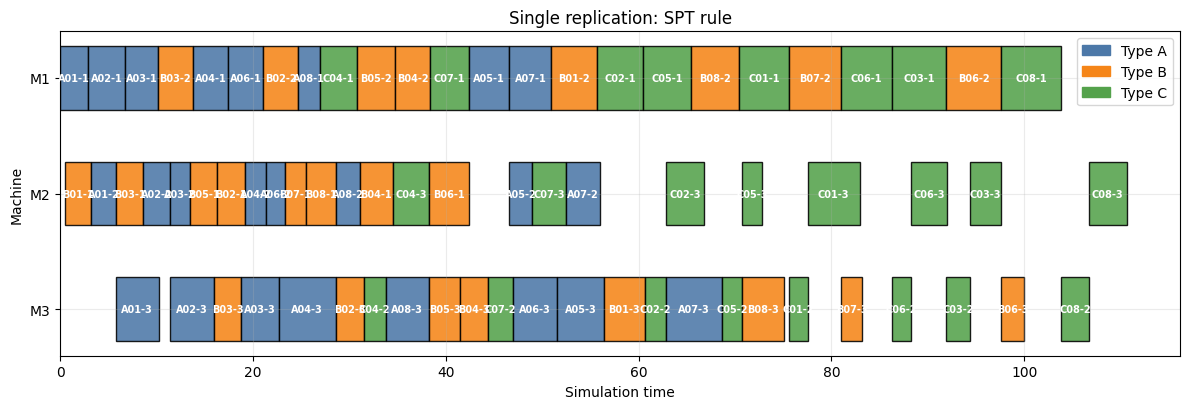

In [21]:
def plot_gantt(operation_df, title="Job shop Gantt chart"):
    # job type별 색상 지정
    colors = {"A": "#4C78A8", "B": "#F58518", "C": "#54A24B"}

    # 기계를 y축 위치로 매핑
    machine_y = {machine: idx for idx, machine in enumerate(MACHINES)}

    fig, ax = plt.subplots(figsize=(12, 4.2))

    # operation 하나를 Gantt chart의 bar 하나로 그림
    for _, row in operation_df.iterrows():
        y = machine_y[row["machine"]]
        job_type = row.get("job_type", row["job"][0])

        ax.barh(
            y=y,
            width=row["duration"],
            left=row["start"],
            height=0.55,
            color=colors[job_type],
            edgecolor="black",
            alpha=0.88,
        )

        # bar 안에 job-operation 라벨 표시
        label = f"{row['job']}-{int(row['operation'])}"
        if row["duration"] >= 1.2:
            ax.text(
                row["start"] + row["duration"] / 2,
                y,
                label,
                ha="center",
                va="center",
                color="white",
                fontsize=7,
                fontweight="bold",
            )

    ax.set_yticks(list(machine_y.values()), list(machine_y.keys()))
    ax.set_xlabel("Simulation time")
    ax.set_ylabel("Machine")
    ax.set_title(title)
    ax.invert_yaxis()

    # job type별 색상 legend
    ax.legend(
        handles=[plt.Rectangle((0, 0), 1, 1, color=color, label=f"Type {job_type}") for job_type, color in colors.items()],
        loc="upper right",
    )

    plt.tight_layout()
    plt.show()


# 단일 SPT 실행 결과를 Gantt chart로 시각화
plot_gantt(single_result["operations"], title="Single replication: SPT rule")

## 7. Rule별 반복실험

확률 기반 시뮬레이션에서는 한 번의 결과만으로 결론을 내리지 않는다. 아래 함수는 각 scheduling rule에 대해 같은 seed 목록을 사용해 반복실험을 수행한다.

`n_replications`를 키우면 평균 추정은 안정적이지만 실행시간이 늘어난다.

In [22]:
def run_replication_experiment(n_replications=100, base_seed=1000, arrival_mode="stochastic", job_counts=None):
    metric_rows = []
    job_rows = []
    job_counts = job_counts or JOB_COUNTS

    # 여러 replication을 반복하여 rule별 성과를 통계적으로 비교
    for rep in range(n_replications):
        scenario_seed = base_seed + rep

        # 같은 replication 안에서는 모든 rule이 동일한 scenario를 사용
        scenario = generate_scenario(seed=scenario_seed, arrival_mode=arrival_mode, job_counts=job_counts)

        for rule in RULES:
            sim = JobShopSimulation(scenario=scenario, rule=rule, random_seed=base_seed * 10 + rep)
            result = sim.run()

            # replication-level metric 저장
            metrics = result["metrics"].copy()
            metrics["replication"] = rep
            metrics["scenario_seed"] = scenario_seed
            metric_rows.append(metrics)

            # job-level 결과도 함께 저장
            jobs = result["jobs"].copy()
            jobs["replication"] = rep
            jobs["scenario_seed"] = scenario_seed
            job_rows.append(jobs)

    return pd.DataFrame(metric_rows), pd.concat(job_rows, ignore_index=True)


# 100회 replication 실행
metrics_df, jobs_df = run_replication_experiment(n_replications=100, base_seed=2026)
metrics_df.head()

,rule,completed_jobs,makespan,throughput,mean_flow_time,mean_waiting_time,mean_tardiness,tardy_jobs,utilization_M1,utilization_M2,utilization_M3,replication,scenario_seed
0,FCFS,24,108.142239,0.221930,51.476028,40.667863,35.253702,23,0.960235,0.679529,0.758891,0,2026
1,SPT,24,110.632140,0.216935,45.608300,34.800136,29.591396,21,0.938624,0.664236,0.741811,0,2026
2,LPT,24,114.425025,0.209744,57.899313,47.091148,41.883211,21,0.907511,0.642218,0.717222,0,2026
3,EDD,24,111.910110,0.214458,48.532965,37.724800,32.396518,22,0.927905,0.656651,0.733340,0,2026
4,RANDOM,24,110.632140,0.216935,54.223335,43.415171,38.174484,21,0.938624,0.664236,0.741811,0,2026


## 8. 평균, 표준편차, 신뢰구간 비교

아래 표의 `ci95_half_width`는 평균에 대한 95% confidence interval의 half-width이다.

정규근사를 사용해 `1.96 * standard error`로 계산한다.

대부분의 지표는 작을수록 좋지만, `throughput`은 클수록 좋다.


In [23]:
# 지표별 최적화 방향 정의
METRIC_GOALS = {
    "makespan": "min",
    "throughput": "max",
    "mean_flow_time": "min",
    "mean_waiting_time": "min",
    "mean_tardiness": "min",
    "tardy_jobs": "min",
}


def summarize_metric(df, metric):
    # rule별 평균, 표준편차, 표본 수 계산
    summary = (
        df.groupby("rule")[metric]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )

    # 표준오차와 95% 신뢰구간 half-width 계산
    summary["standard_error"] = summary["std"] / np.sqrt(summary["count"])
    summary["ci95_half_width"] = 1.96 * summary["standard_error"]

    # 낮을수록 좋은 지표와 높을수록 좋은 지표를 구분해 정렬
    ascending = METRIC_GOALS.get(metric, "min") == "min"
    return summary.sort_values("mean", ascending=ascending).reset_index(drop=True)


main_metrics = list(METRIC_GOALS)

# 주요 성과지표별 요약표 생성
summary_tables = {metric: summarize_metric(metrics_df, metric) for metric in main_metrics}

# makespan 요약표 확인
summary_tables["makespan"]

,rule,mean,std,count,standard_error,ci95_half_width
0,FCFS,104.366924,4.421667,100,0.442167,0.866647
1,SPT,105.469796,5.063066,100,0.506307,0.992361
2,EDD,107.110267,4.974463,100,0.497446,0.974995
3,RANDOM,107.808984,4.952425,100,0.495243,0.970675
4,LPT,115.428867,5.011446,100,0.501145,0.982243


In [24]:
# 모든 주요 지표의 rule별 요약표 출력
for metric in main_metrics:
    print(f"\n=== {metric} ===")
    display(summary_tables[metric])


=== makespan ===


,rule,mean,std,count,standard_error,ci95_half_width
0,FCFS,104.366924,4.421667,100,0.442167,0.866647
1,SPT,105.469796,5.063066,100,0.506307,0.992361
2,EDD,107.110267,4.974463,100,0.497446,0.974995
3,RANDOM,107.808984,4.952425,100,0.495243,0.970675
4,LPT,115.428867,5.011446,100,0.501145,0.982243



=== throughput ===


,rule,mean,std,count,standard_error,ci95_half_width
0,FCFS,0.230365,0.009717,100,0.000972,0.001904
1,SPT,0.228069,0.010872,100,0.001087,0.002131
2,EDD,0.224544,0.010384,100,0.001038,0.002035
3,RANDOM,0.223086,0.010348,100,0.001035,0.002028
4,LPT,0.208311,0.009096,100,0.000910,0.001783



=== mean_flow_time ===


...

,rule,mean,std,count,standard_error,ci95_half_width
0,SPT,37.035442,3.009838,100,0.300984,0.589928
1,EDD,39.657356,2.935072,100,0.293507,0.575274
2,RANDOM,42.923861,3.637997,100,0.363800,0.713047
3,FCFS,43.078371,3.744578,100,0.374458,0.733937
4,LPT,48.528734,3.783445,100,0.378345,0.741555



=== mean_tardiness ===


,rule,mean,std,count,standard_error,ci95_half_width
0,SPT,31.509000,3.117285,100,0.311729,0.610988
1,EDD,34.029032,3.098721,100,0.309872,0.607349
2,RANDOM,37.255171,3.731701,100,0.373170,0.731413
3,FCFS,37.330187,3.849356,100,0.384936,0.754474
4,LPT,42.894599,3.894885,100,0.389489,0.763397



=== tardy_jobs ===


,rule,mean,std,count,standard_error,ci95_half_width
0,SPT,21.26,1.115728,100,0.111573,0.218683
1,LPT,22.07,1.174261,100,0.117426,0.230155
2,EDD,22.17,0.682464,100,0.068246,0.133763
3,RANDOM,22.49,0.979538,100,0.097954,0.191989
4,FCFS,23.10,0.745356,100,0.074536,0.146090


## 9. 시각화: 평균과 변동성

Bar chart는 rule별 평균과 신뢰구간을 보기 좋고, boxplot은 replication별 결과 분포를 확인하기 좋다.

`throughput`은 클수록 좋은 지표이고, makespan/waiting/tardiness는 작을수록 좋은 지표다.


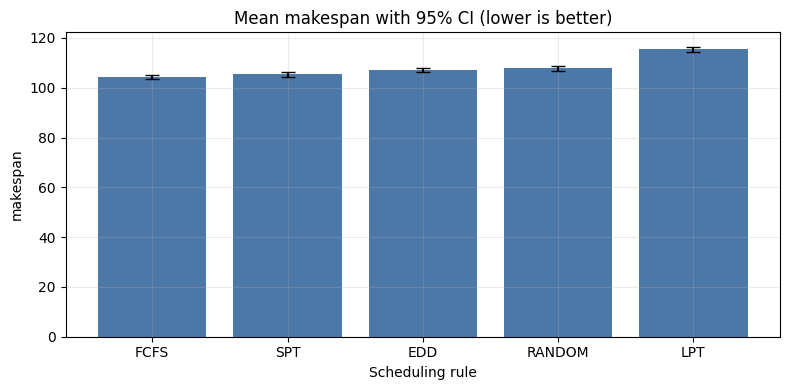

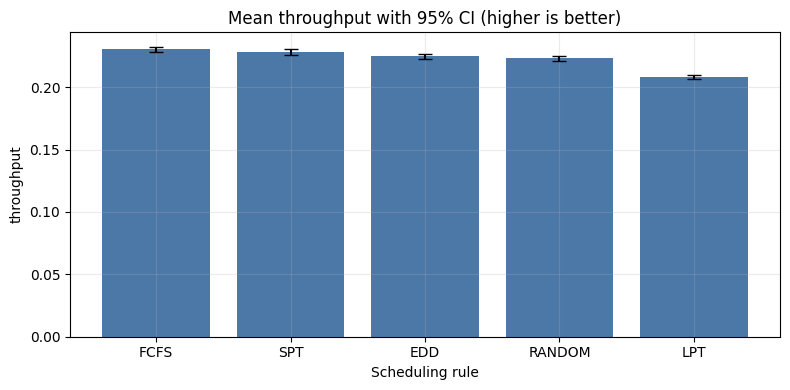

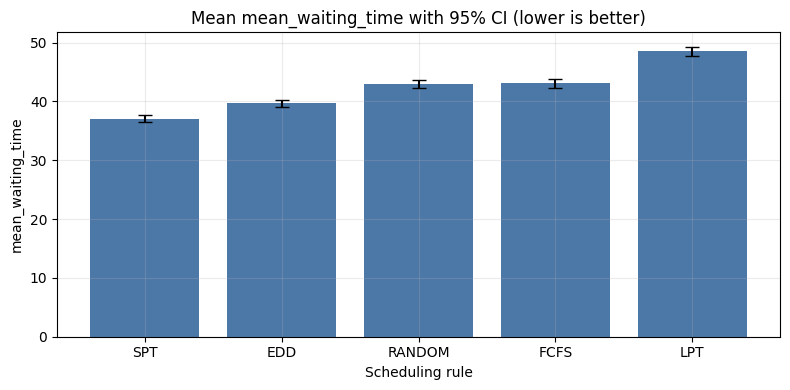

In [25]:
def plot_metric_with_ci(summary, metric, title=None):
    fig, ax = plt.subplots(figsize=(8, 4))

    # rule별 평균값과 95% 신뢰구간을 bar chart로 표시
    ax.bar(summary["rule"], summary["mean"], yerr=summary["ci95_half_width"], capsize=5, color="#4C78A8")

    ax.set_xlabel("Scheduling rule")
    ax.set_ylabel(metric)

    # 지표 해석 방향을 제목에 표시
    goal = "higher is better" if METRIC_GOALS.get(metric) == "max" else "lower is better"
    ax.set_title(title or f"Mean {metric} with 95% CI ({goal})")

    plt.tight_layout()
    plt.show()


# 핵심 지표에 대한 평균 및 신뢰구간 시각화
plot_metric_with_ci(summary_tables["makespan"], "makespan")
plot_metric_with_ci(summary_tables["throughput"], "throughput")
plot_metric_with_ci(summary_tables["mean_waiting_time"], "mean_waiting_time")

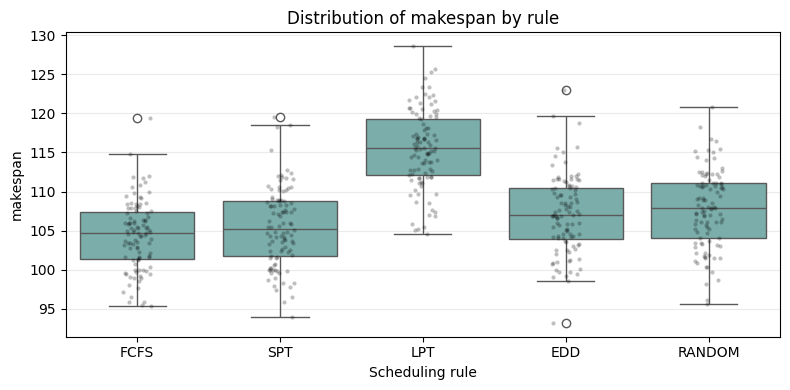

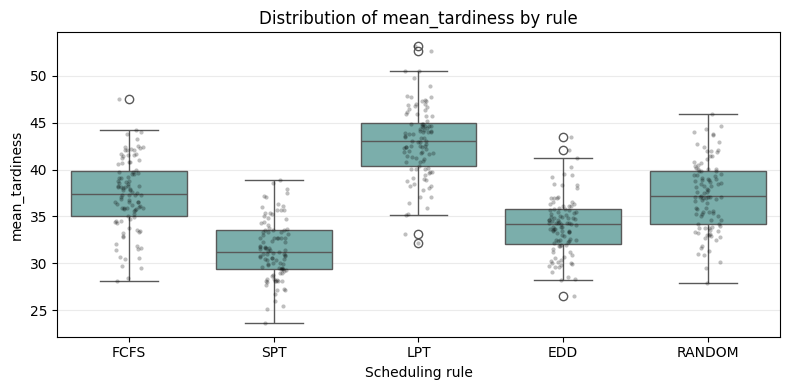

In [26]:
def plot_metric_distribution(df, metric):
    fig, ax = plt.subplots(figsize=(8, 4))

    # seaborn이 있으면 boxplot + stripplot으로 분포를 더 자세히 표현
    if HAS_SEABORN:
        sns.boxplot(data=df, x="rule", y=metric, ax=ax, color="#72B7B2")
        sns.stripplot(data=df, x="rule", y=metric, ax=ax, color="black", alpha=0.25, size=3)

    # seaborn이 없으면 matplotlib 기본 boxplot 사용
    else:
        grouped = [df.loc[df["rule"] == rule, metric].values for rule in RULES]
        ax.boxplot(grouped, labels=RULES)

    ax.set_xlabel("Scheduling rule")
    ax.set_ylabel(metric)
    ax.set_title(f"Distribution of {metric} by rule")

    plt.tight_layout()
    plt.show()


# makespan과 tardiness 분포 비교
plot_metric_distribution(metrics_df, "makespan")
plot_metric_distribution(metrics_df, "mean_tardiness")

## 10. Machine utilization과 병목 해석

Utilization은 각 machine이 전체 makespan 중 실제 처리에 사용된 비율이다. 값이 높은 machine은 병목 후보로 볼 수 있다.

,rule,utilization_M1,utilization_M2,utilization_M3
0,EDD,0.928688,0.677886,0.766353
1,FCFS,0.952916,0.695478,0.786197
2,LPT,0.862140,0.628754,0.710835
3,RANDOM,0.922787,0.673617,0.761564
4,SPT,0.943074,0.688735,0.778502


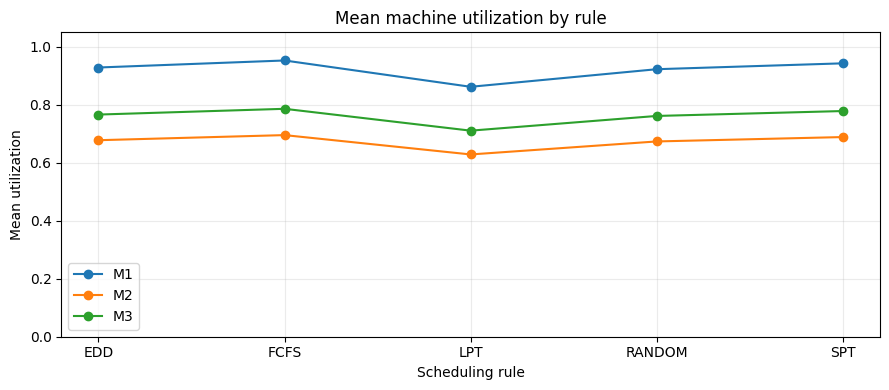

In [27]:
# 기계별 utilization 컬럼 선택
util_cols = [f"utilization_{m}" for m in MACHINES]

# rule별 평균 utilization 계산
util_summary = metrics_df.groupby("rule")[util_cols].mean().reset_index()
display(util_summary)

# 시각화를 위해 wide format을 long format으로 변환
util_long = util_summary.melt(id_vars="rule", var_name="machine", value_name="mean_utilization")
util_long["machine"] = util_long["machine"].str.replace("utilization_", "", regex=False)

fig, ax = plt.subplots(figsize=(9, 4))

# 기계별 utilization 변화를 rule 축에서 비교
for machine in MACHINES:
    subset = util_long[util_long["machine"] == machine]
    ax.plot(subset["rule"], subset["mean_utilization"], marker="o", label=machine)

ax.set_ylim(0, 1.05)
ax.set_xlabel("Scheduling rule")
ax.set_ylabel("Mean utilization")
ax.set_title("Mean machine utilization by rule")
ax.legend()

plt.tight_layout()
plt.show()

## 11. 결과 해석 가이드

수업에서 결과를 해석할 때는 아래 질문을 던지면 좋다.

1. Makespan이 가장 작은 rule은 무엇인가?
2. Throughput이 가장 큰 rule은 무엇인가?
3. Mean waiting time이 가장 작은 rule은 무엇인가?
4. Mean tardiness가 가장 작은 rule은 무엇인가?
5. 평균은 좋아도 변동성이 큰 rule이 있는가?
6. Utilization이 높은 machine은 어느 machine인가?
7. 같은 rule이 모든 성과지표에서 항상 좋은가?

일반적으로 SPT는 평균 flow time이나 waiting time을 줄이는 데 유리할 수 있고, EDD는 due date 관련 지표를 줄이는 데 유리할 수 있다. 하지만 job routing, processing time distribution, arrival pattern, job type mix에 따라 결과는 달라질 수 있으므로 반복실험 결과로 판단해야 한다.


In [28]:
best_by_metric = []

# 각 성과지표에서 가장 좋은 rule을 선택
for metric in main_metrics:
    row = summary_tables[metric].iloc[0]

    best_by_metric.append({
        "metric": metric,
        "optimization_direction": "highest" if METRIC_GOALS[metric] == "max" else "lowest",
        "best_rule": row["rule"],
        "mean": row["mean"],
        "ci95_half_width": row["ci95_half_width"],
    })

# 지표별 best scheduling rule 요약
pd.DataFrame(best_by_metric)

,metric,optimization_direction,best_rule,mean,ci95_half_width
0,makespan,lowest,FCFS,104.366924,0.866647
1,throughput,highest,FCFS,0.230365,0.001904
2,mean_flow_time,lowest,SPT,47.614480,0.627857
3,mean_waiting_time,lowest,SPT,37.035442,0.589928
4,mean_tardiness,lowest,SPT,31.509000,0.610988
5,tardy_jobs,lowest,SPT,21.260000,0.218683
